In [1]:
# import numpy as np
# import pandas as pd
# import time

# # Load the real OASIS data we processed in Notebook 1
# X_train_df = pd.read_csv('../dataset/processed/X_train.csv')
# y_train_df = pd.read_csv('../dataset/processed/Y_train.csv')
# X_test_df = pd.read_csv('../dataset/processed/X_test.csv')
# y_test_df = pd.read_csv('../dataset/processed/Y_test.csv')

# # Convert to pure numpy arrays for our custom math
# X_train = X_train_df.values
# y_train = y_train_df.values.ravel()
# X_test = X_test_df.values
# y_test = y_test_df.values.ravel()

# print(f"Training shape: {X_train.shape}")
# print(f"Sample labels for Logistic Regression: {y_train[:10]}")

In [2]:
import numpy as np
import pandas as pd
import time
import joblib
import os

# Create the models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# 1. Load Original Data (75-patient test set)
X_train_orig = pd.read_csv('../dataset/processed/X_train.csv').values
y_train_orig = pd.read_csv('../dataset/processed/Y_train.csv').values.ravel()
X_test_orig = pd.read_csv('../dataset/processed/X_test.csv').values
y_test_orig = pd.read_csv('../dataset/processed/Y_test.csv').values.ravel()

# 2. Load New Merged Data (Generalized dataset)
X_train_merged = pd.read_csv('../dataset/processed_merged/X_train.csv').values
y_train_merged = pd.read_csv('../dataset/processed_merged/Y_train.csv').values.ravel()
X_test_merged = pd.read_csv('../dataset/processed_merged/X_test.csv').values
y_test_merged = pd.read_csv('../dataset/processed_merged/Y_test.csv').values.ravel()

print(f"Original Training Size: {X_train_orig.shape[0]} patients")
print(f"Merged Training Size: {X_train_merged.shape[0]} patients")

Original Training Size: 304 patients
Merged Training Size: 460 patients


In [3]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=2000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def _sigmoid(self, x):
        """Squashes any number into a probability between 0 and 1."""
        # np.clip prevents overflow errors if numbers get too massive
        x = np.clip(x, -250, 250)
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent Loop
        for _ in range(self.n_iters):
            # 1. Calculate the linear combination (z = w*X + b)
            linear_model = np.dot(X, self.weights) + self.bias
            
            # 2. Apply Sigmoid to get probabilities
            y_predicted = self._sigmoid(linear_model)

            # 3. Calculate Gradients (Derivatives of Log Loss)
            # How much should we change weights and bias to fix the errors?
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # 4. Update the weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        """Returns the raw probabilities (e.g., 0.85 means 85% chance of Alzheimer's)."""
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        """Converts probabilities into hard 0 or 1 classes based on a threshold."""
        y_predicted = self.predict_proba(X)
        return np.array([1 if i > threshold else 0 for i in y_predicted])

In [4]:
def calculate_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def calculate_recall(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_negatives = np.sum((y_true == 1) & (y_pred == 0))
    if (true_positives + false_negatives) == 0: return 0
    return true_positives / (true_positives + false_negatives)

def calculate_f1(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = calculate_recall(y_true, y_pred)
    if (precision + recall) == 0: return 0
    return 2 * (precision * recall) / (precision + recall)

In [5]:
# --- EXPERIMENT A: ORIGINAL DATA ---
print("--- MODEL A: ORIGINAL DATASET (LOGISTIC REGRESSION) ---")
start_time = time.time()
logreg_original = CustomLogisticRegression(learning_rate=0.05, n_iters=2000)
logreg_original.fit(X_train_orig, y_train_orig)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_orig = logreg_original.predict(X_test_orig)
print(f"Accuracy: {calculate_accuracy(y_test_orig, preds_orig):.4f}")
print(f"Recall:   {calculate_recall(y_test_orig, preds_orig):.4f}")
print(f"F1-Score: {calculate_f1(y_test_orig, preds_orig):.4f}")

# Save the original model
joblib.dump(logreg_original, '../models/logreg_original.joblib')


# --- EXPERIMENT B: MERGED DATA ---
print("\n--- MODEL B: GENERALIZED MERGED DATASET (LOGISTIC REGRESSION) ---")
start_time = time.time()
logreg_merged = CustomLogisticRegression(learning_rate=0.05, n_iters=2000)
logreg_merged.fit(X_train_merged, y_train_merged)
print(f"Training Time: {time.time() - start_time:.2f} seconds")

preds_merged = logreg_merged.predict(X_test_merged)
print(f"Accuracy: {calculate_accuracy(y_test_merged, preds_merged):.4f}")
print(f"Recall:   {calculate_recall(y_test_merged, preds_merged):.4f}")
print(f"F1-Score: {calculate_f1(y_test_merged, preds_merged):.4f}")

# Save the generalized model
joblib.dump(logreg_merged, '../models/logreg_merged.joblib')

print("\nModels successfully saved to the '../models/' directory.")

--- MODEL A: ORIGINAL DATASET (LOGISTIC REGRESSION) ---
Training Time: 0.31 seconds
Accuracy: 0.7467
Recall:   0.6757
F1-Score: 0.7246

--- MODEL B: GENERALIZED MERGED DATASET (LOGISTIC REGRESSION) ---
Training Time: 0.14 seconds
Accuracy: 0.8000
Recall:   0.7719
F1-Score: 0.7928

Models successfully saved to the '../models/' directory.


In [8]:
# # Find the indices where the prediction does NOT match the real label
# wrong_predictions_indices = np.where(y_test != logreg_predictions)[0]

# print("Indices of misclassified patients:", wrong_predictions_indices)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# The exact feature order from your preprocessed data
feature_names = ['M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']

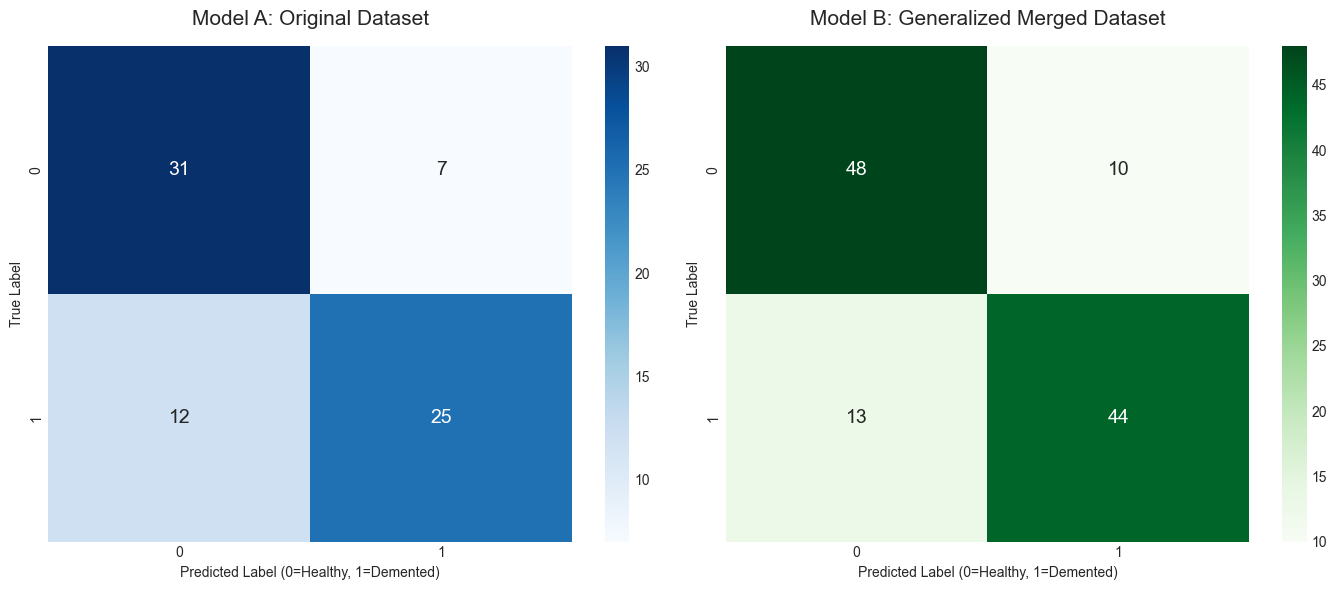

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Original Dataset Confusion Matrix
cm_orig = confusion_matrix(y_test_orig, preds_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Model A: Original Dataset', fontsize=15, pad=15)
axes[0].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[0].set_ylabel('True Label')

# 2. Merged Dataset Confusion Matrix
cm_merged = confusion_matrix(y_test_merged, preds_merged)
sns.heatmap(cm_merged, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Model B: Generalized Merged Dataset', fontsize=15, pad=15)
axes[1].set_xlabel('Predicted Label (0=Healthy, 1=Demented)')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../figures/lr_confusion_matrices.png', dpi=300)
plt.show()

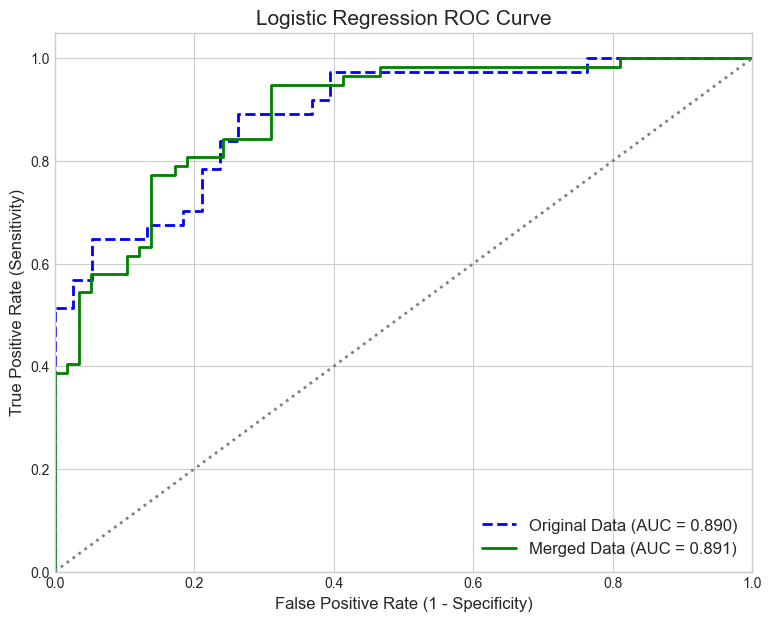

In [11]:
# Get raw probabilities (0.0 to 1.0) directly from your custom Sigmoid function
probs_orig = logreg_original.predict_proba(X_test_orig)
probs_merged = logreg_merged.predict_proba(X_test_merged)

# Calculate ROC metrics
fpr_orig, tpr_orig, _ = roc_curve(y_test_orig, probs_orig)
auc_orig = auc(fpr_orig, tpr_orig)

fpr_merged, tpr_merged, _ = roc_curve(y_test_merged, probs_merged)
auc_merged = auc(fpr_merged, tpr_merged)

# Plot
plt.figure(figsize=(9, 7))
plt.plot(fpr_orig, tpr_orig, color='blue', lw=2, linestyle='--', label=f'Original Data (AUC = {auc_orig:.3f})')
plt.plot(fpr_merged, tpr_merged, color='green', lw=2, label=f'Merged Data (AUC = {auc_merged:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Logistic Regression ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

plt.savefig('../figures/lr_roc_curve.png', dpi=300)
plt.show()

Extracting learned coefficients (weights)...


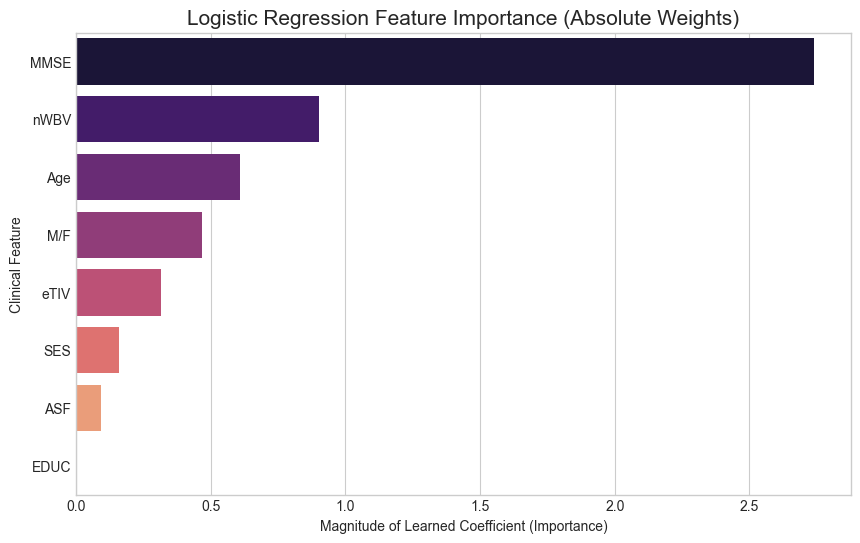

In [12]:
print("Extracting learned coefficients (weights)...")

# Get absolute values of the learned weights from the generalized model
importance_weights = np.abs(logreg_merged.weights)

# Create a DataFrame for sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Weight Magnitude': importance_weights
})
# Sort by highest weight
importance_df = importance_df.sort_values(by='Weight Magnitude', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Weight Magnitude', y='Feature', data=importance_df, palette='magma')
plt.title('Logistic Regression Feature Importance (Absolute Weights)', fontsize=15)
plt.xlabel('Magnitude of Learned Coefficient (Importance)')
plt.ylabel('Clinical Feature')

plt.savefig('../figures/lr_feature_importance.png', dpi=300)
plt.show()

Training 2D Logistic Regression for Visualization...


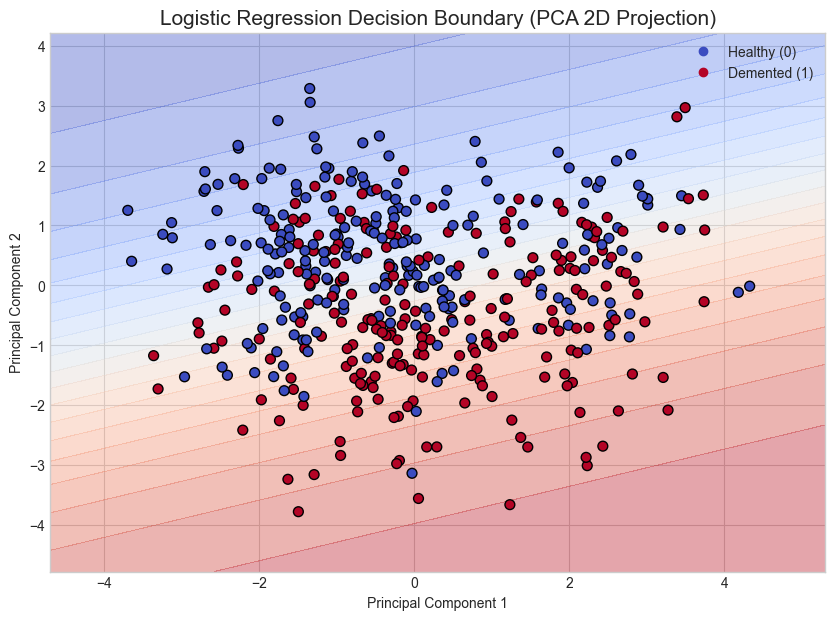

In [13]:
# 1. Compress features to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_merged)
y_train_pca = y_train_merged

# 2. Train a 2D Presentation Logistic Regression Model
print("Training 2D Logistic Regression for Visualization...")
lr_2d = CustomLogisticRegression(learning_rate=0.05, n_iters=1000)
lr_2d.fit(X_train_pca, y_train_pca)

# 3. Create the mesh grid (background pixels)
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# 4. Predict probabilities across the grid (to show the Sigmoid gradient!)
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = lr_2d.predict_proba(grid_points)
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(10, 7))
# contourf with probabilities creates a beautiful gradient showing the boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm', levels=20) 
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap='coolwarm', edgecolor='k', s=50)

plt.title('Logistic Regression Decision Boundary (PCA 2D Projection)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Healthy (0)', 'Demented (1)'], loc="upper right")

plt.savefig('../figures/lr_decision_boundary.png', dpi=300)
plt.show()